<a href="https://colab.research.google.com/github/nethuli-dev/traffic-accident-severity-prediction/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
!pip install kaggle -q

import pandas as pd      # data loading & manipulation
import numpy as np       # numerical operations
import matplotlib.pyplot as plt   # base plotting
import seaborn as sns    # nicer statistical plots, built on matplotlib
from scipy import stats  # chi-square test, correlation tests

sns.set_theme(style="whitegrid")   # makes charts readable by default
pd.set_option("display.max_columns", 100)  # don't truncate wide dataframes when printing

In [52]:
import os
os.makedirs("reports/figures", exist_ok=True)

In [39]:
!git clone https://github.com/nethuli-dev/traffic-accident-severity-prediction.git
%cd traffic-accident-severity-prediction

fatal: destination path 'traffic-accident-severity-prediction' already exists and is not an empty directory.
/content/traffic-accident-severity-prediction/traffic-accident-severity-prediction


In [40]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_8e633847bbd5e14474273e7e593897cc"
!kaggle datasets download -d sobhanmoosavi/us-accidents -p data/raw --unzip

Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
License(s): CC-BY-NC-SA-4.0
100% 653M/653M [00:11<00:00, 58.0MB/s]



In [41]:
!ls -lh data/raw

total 2.9G
-rw-r--r-- 1 root root 2.9G Aug  4 19:02 US_Accidents_March23.csv


In [42]:
#Load the dataset
df_sample = pd.read_csv("/content/traffic-accident-severity-prediction/data/raw/US_Accidents_March23.csv", nrows=5)
print(df_sample.shape)
print(df_sample.dtypes)
print(df_sample.head())

(5, 46)
ID                        object
Source                    object
Severity                   int64
Start_Time                object
End_Time                  object
Start_Lat                float64
Start_Lng                float64
End_Lat                  float64
End_Lng                  float64
Distance(mi)             float64
Description               object
Street                    object
City                      object
County                    object
State                     object
Zipcode                   object
Country                   object
Timezone                  object
Airport_Code              object
Weather_Timestamp         object
Temperature(F)           float64
Wind_Chill(F)            float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)           float64
Wind_Direction            object
Wind_Speed(mph)          float64
Precipitation(in)        float64
Weather_Condition         object
Amenity                     bool
Bu

In [43]:
#Row count
with open("/content/traffic-accident-severity-prediction/data/raw/US_Accidents_March23.csv") as f:
    n_rows = sum(1 for _ in f) - 1
print(f"Total rows: {n_rows:,}")

Total rows: 7,728,394


In [44]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       2.0Gi       901Mi       4.0Mi       9.8Gi        10Gi
Swap:             0B          0B          0B


In [45]:
#The dtype map
bool_cols = [
    "Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit", "Railway",
    "Roundabout", "Station", "Stop", "Traffic_Calming", "Traffic_Signal", "Turning_Loop"
]
float32_cols = [
    "Start_Lat", "Start_Lng", "End_Lat", "End_Lng", "Distance(mi)",
    "Temperature(F)", "Wind_Chill(F)", "Humidity(%)", "Pressure(in)",
    "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)"
]
category_cols = [
    "Source", "State", "Timezone", "Weather_Condition", "Wind_Direction",
    "Sunrise_Sunset", "Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight"
]

dtype_map = {}
for c in bool_cols:
    dtype_map[c] = "boolean"
for c in float32_cols:
    dtype_map[c] = "float32"
for c in category_cols:
    dtype_map[c] = "category"
dtype_map["Severity"] = "int8"

parse_dates = ["Start_Time", "End_Time", "Weather_Timestamp"]
print(f"{len(dtype_map)} columns typed, {len(parse_dates)} parsed as dates.")

35 columns typed, 3 parsed as dates.


In [46]:
#Full Load
DATA_PATH = "/content/traffic-accident-severity-prediction/data/raw/US_Accidents_March23.csv"


In [47]:
# Load Sample data from Dataset
df_sample = pd.read_csv(DATA_PATH, dtype=dtype_map, parse_dates=parse_dates, low_memory=False,
                         skiprows=lambda i: i > 0 and np.random.rand() > 0.15)
print(df_sample.shape)
print("Memory:", round(df.memory_usage(deep=True).sum() / 1e9, 2), "GB")

(1160697, 46)
Memory: 0.8 GB


In [48]:
print(df["Severity"].value_counts(normalize=True).round(4))

Severity
2    0.7970
3    0.1680
4    0.0264
1    0.0086
Name: proportion, dtype: float64


In [49]:
# Missing Value Audit
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0].round(2)
print(missing_pct)

End_Lat                  44.00
End_Lng                  44.00
Precipitation(in)        28.52
Wind_Chill(F)            25.88
End_Time                  9.63
Start_Time                9.63
hour                      9.63
Wind_Speed(mph)           7.41
Visibility(mi)            2.28
Wind_Direction            2.26
Weather_Condition         2.24
Humidity(%)               2.24
Temperature(F)            2.11
Pressure(in)              1.81
Weather_Timestamp         1.55
Civil_Twilight            0.30
Nautical_Twilight         0.30
Astronomical_Twilight     0.30
Sunrise_Sunset            0.30
Airport_Code              0.29
Street                    0.15
Timezone                  0.10
Zipcode                   0.03
City                      0.00
dtype: float64


In [50]:
# Informative missingness check: does weather-field missingness cluster by state?
# (rural states with fewer weather stations should show higher missingness)
weather_cols = ["Temperature(F)", "Wind_Chill(F)", "Humidity(%)",
                 "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)"]

df["weather_missing_count"] = df[weather_cols].isna().sum(axis=1)

state_missingness = (
    df.groupby("State", observed=True)["weather_missing_count"]
      .mean()
      .sort_values(ascending=False)
)
print(state_missingness.head(10))   # states with worst weather-field coverage
print(state_missingness.tail(10))   # states with best coverage

State
MD    1.461845
NE    1.165400
WY    1.138060
KS    1.121270
UT    0.963828
VT    0.959184
RI    0.946071
TX    0.916069
GA    0.900607
NH    0.883544
Name: weather_missing_count, dtype: float64
State
DC    0.487971
TN    0.471906
CT    0.456524
DE    0.427321
MN    0.407100
WV    0.305529
ID    0.275822
AR    0.270833
SD    0.261905
MT    0.196204
Name: weather_missing_count, dtype: float64


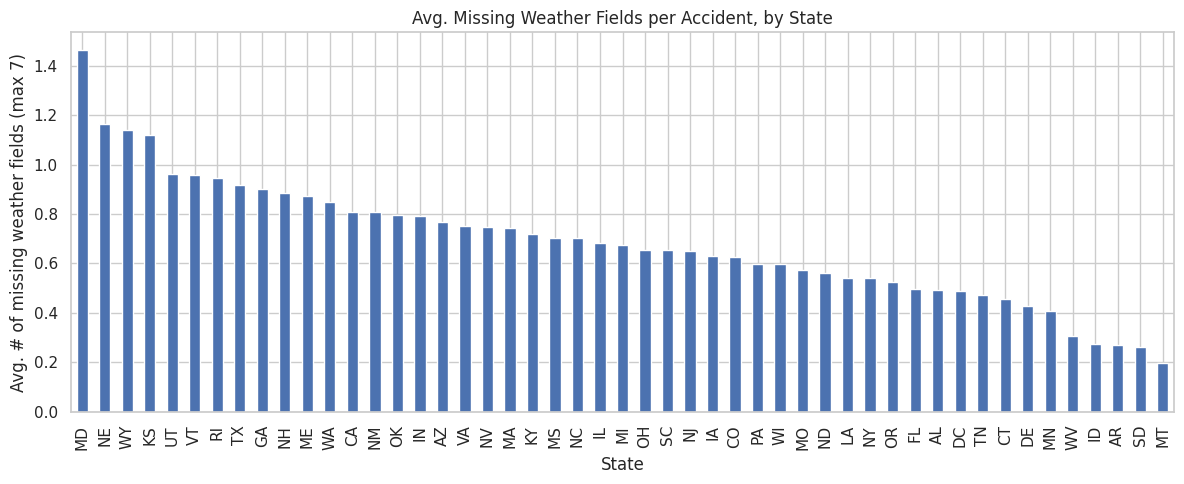

In [53]:
# Visualization
plt.figure(figsize=(12, 5))
state_missingness.sort_values(ascending=False).plot(kind="bar")
plt.title("Avg. Missing Weather Fields per Accident, by State")
plt.ylabel("Avg. # of missing weather fields (max 7)")
plt.xlabel("State")
plt.tight_layout()
plt.savefig("reports/figures/weather_missingness_by_state.png", dpi=150)
plt.show()

In [54]:
# Checking duplicates
n_dupe_ids = df["ID"].duplicated().sum()
print(f"Duplicate ID rows: {n_dupe_ids}")

# Also check for exact full-row duplicates (different issue than duplicate IDs)
n_dupe_rows = df.duplicated().sum()
print(f"Fully duplicate rows: {n_dupe_rows}")

Duplicate ID rows: 0
Fully duplicate rows: 0


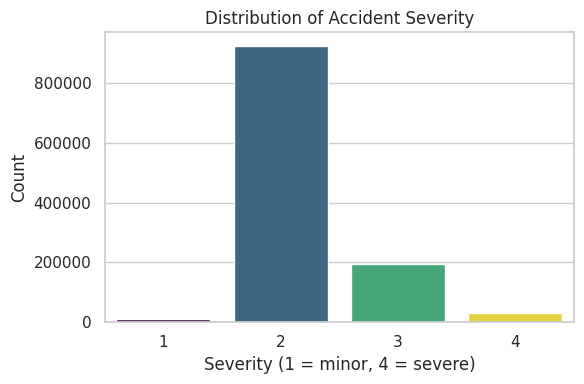

In [55]:
# Severity Distribution Chart
plt.figure(figsize=(6, 4))
sns.countplot(x="Severity", data=df, order=[1, 2, 3, 4], hue="Severity",
              palette="viridis", legend=False)
plt.title("Distribution of Accident Severity")
plt.xlabel("Severity (1 = minor, 4 = severe)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("reports/figures/severity_distribution.png", dpi=150)
plt.show()

In [56]:
print(df["Start_Time"].dtype)
print(df["Start_Time"].head(3))

datetime64[ns]
0   2016-02-08 06:49:27
1   2016-02-08 08:14:42
2   2016-02-08 09:25:17
Name: Start_Time, dtype: datetime64[ns]


In [60]:
# Explicitly parse datetime columns (read_csv's parse_dates silently didn't take effect)
for col in ["Start_Time", "End_Time", "Weather_Timestamp"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print(df[["Start_Time", "End_Time", "Weather_Timestamp"]].dtypes)

Start_Time           datetime64[ns]
End_Time             datetime64[ns]
Weather_Timestamp    datetime64[ns]
dtype: object


In [57]:
print("Unparseable Start_Time rows:", df["Start_Time"].isna().sum())

Unparseable Start_Time rows: 111686


In [58]:
df["hour"] = df["Start_Time"].dt.hour

In [59]:
#Hour-of-day vs severity(Chi-square)

df["hour"] = df["Start_Time"].dt.hour

def hour_bucket(h):
    if 6 <= h < 10: return "morning_rush"
    elif 10 <= h < 16: return "midday"
    elif 16 <= h < 19: return "evening_rush"
    elif 19 <= h < 23: return "evening"
    else: return "overnight"

df["hour_bucket"] = df["hour"].apply(hour_bucket)

contingency = pd.crosstab(df["hour_bucket"], df["Severity"])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square: {chi2:.2f}, p-value: {p:.4g}, dof: {dof}")

# Effect size (Cramér's V) — chi-square alone is misleading at this row count,
# since even trivial associations become "significant" with 1M+ rows
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
print(f"Cramér's V: {cramers_v:.4f}")

Chi-square: 21654.16, p-value: 0, dof: 12
Cramér's V: 0.0789


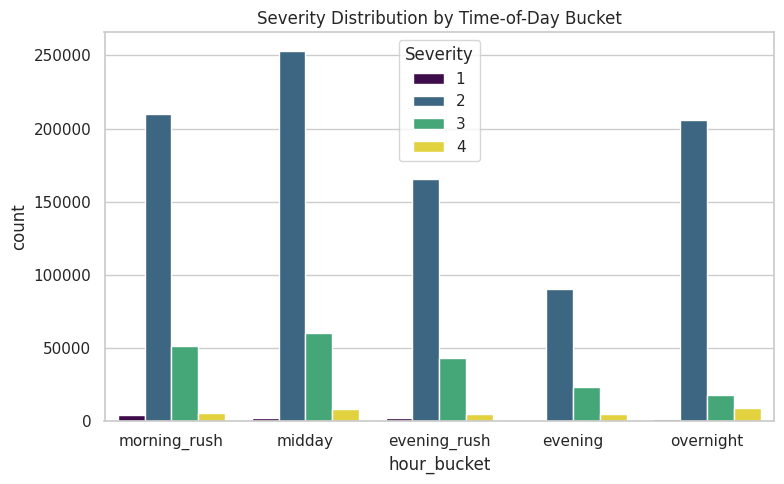

In [61]:
#Visualization for Severity Distribution by Time-of-Day Bucket
plt.figure(figsize=(8, 5))
sns.countplot(x="hour_bucket", hue="Severity",
              order=["morning_rush", "midday", "evening_rush", "evening", "overnight"],
              data=df, palette="viridis")
plt.title("Severity Distribution by Time-of-Day Bucket")
plt.tight_layout()
plt.savefig("reports/figures/severity_by_hour_bucket.png", dpi=150)
plt.show()

In [62]:
#Weather vs severity

top_weather = df["Weather_Condition"].value_counts().head(10).index
weather_subset = df[df["Weather_Condition"].isin(top_weather)]

contingency_w = pd.crosstab(weather_subset["Weather_Condition"], weather_subset["Severity"])
chi2_w, p_w, dof_w, _ = stats.chi2_contingency(contingency_w)
n_w = contingency_w.sum().sum()
cramers_v_w = np.sqrt(chi2_w / (n_w * (min(contingency_w.shape) - 1)))
print(f"Weather -> Severity | Chi2: {chi2_w:.2f}, p: {p_w:.4g}, Cramér's V: {cramers_v_w:.4f}")

mean_sev_by_weather = df.groupby("Weather_Condition", observed=True)["Severity"].mean().sort_values(ascending=False)
print(mean_sev_by_weather.head(15))

Weather -> Severity | Chi2: 52161.15, p: 0, Cramér's V: 0.1280
Weather_Condition
Drifting Snow / Windy           3.000000
Heavy Snow with Thunder         3.000000
Heavy Thunderstorms and Snow    3.000000
Light Fog                       3.000000
Light Haze                      3.000000
Heavy Rain Showers              3.000000
Heavy Ice Pellets               3.000000
Light Thunderstorms and Snow    3.000000
Light Snow Showers              3.000000
Patches of Fog / Windy          3.000000
Rain and Sleet                  3.000000
Thunder and Hail / Windy        3.000000
Ice Pellets                     2.545455
Light Ice Pellets               2.511628
Freezing Drizzle                2.500000
Name: Severity, dtype: float64


In [63]:
#Geographic clustering — severity rate relative to volume, not raw count

state_stats = df.groupby("State", observed=True).agg(
    total_accidents=("Severity", "count"),
    severe_rate=("Severity", lambda s: (s >= 3).mean())
).sort_values("severe_rate", ascending=False)

print(state_stats.head(10))   # highest severe-accident RATE, not just volume

       total_accidents  severe_rate
State                              
RI                2596     0.462250
GA               25535     0.433718
KY                4858     0.419720
CO               13539     0.378979
IL               25347     0.371721
WI                5222     0.367101
MO               11636     0.362925
IA                3836     0.347497
NM                1471     0.333787
VT                 147     0.333333


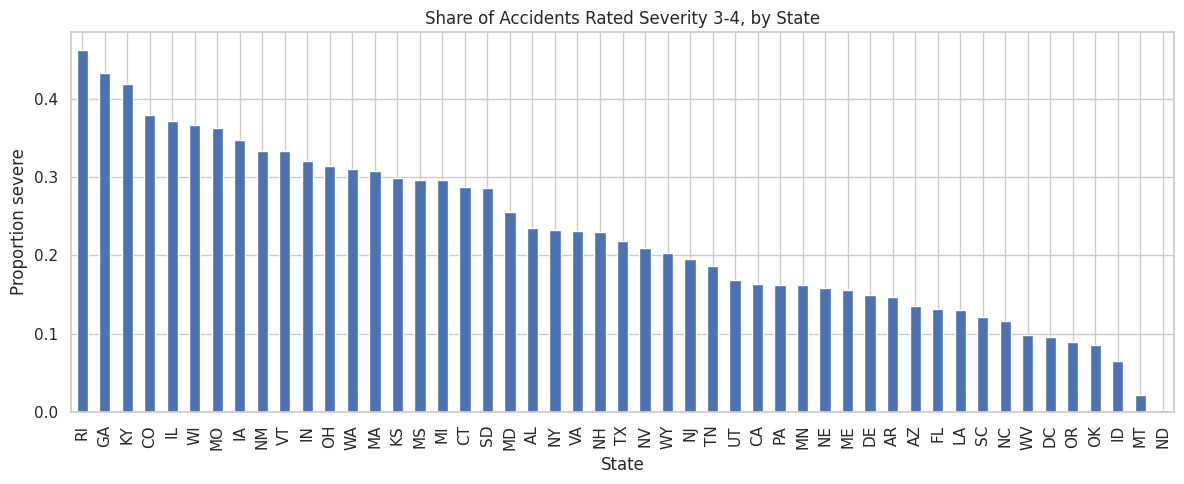

In [64]:
#Visualization for Share of Accidents Rated Severity 3-4, by State
plt.figure(figsize=(12, 5))
state_stats.sort_values("severe_rate", ascending=False)["severe_rate"].plot(kind="bar")
plt.title("Share of Accidents Rated Severity 3-4, by State")
plt.ylabel("Proportion severe")
plt.tight_layout()
plt.savefig("reports/figures/severe_rate_by_state.png", dpi=150)
plt.show()

Spearman correlation, Distance(mi) vs Severity: -0.138


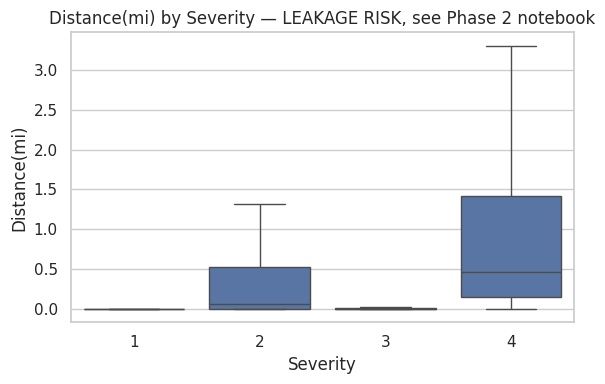

In [65]:
#Distance(mi) leakage flag — quantify it now, decide in Phase 2
distance_corr = df[["Distance(mi)", "Severity"]].corr(method="spearman").iloc[0, 1]
print(f"Spearman correlation, Distance(mi) vs Severity: {distance_corr:.3f}")

plt.figure(figsize=(6, 4))
sns.boxplot(x="Severity", y="Distance(mi)", data=df, showfliers=False)
plt.title("Distance(mi) by Severity — LEAKAGE RISK, see Phase 2 notebook")
plt.tight_layout()
plt.savefig("reports/figures/distance_leakage_flag.png", dpi=150)
plt.show()

In [66]:
%cd /content/traffic-accident-severity-prediction
!pwd

/content/traffic-accident-severity-prediction
/content/traffic-accident-severity-prediction
